# LangChain Conversational Assistant (RAG)


This notebook implements a **Retrieval-Augmented Generation (RAG)** conversational assistant that:
1. Loads 6 architectural style documents into a **Chroma** vector store
2. Accepts a building photo, runs it through the **Part B CV model**, and retrieves relevant knowledge
3. Generates grounded, cited explanations using **Llama 3.2** via **Ollama**
4. Maintains **multi-turn conversation memory** across 3+ exchanges
5. Handles edge cases: low confidence, out-of-scope questions, empty retrieval

---


### Notebook Structure
1. Setup & Health Checks
2. Knowledge Base Loading
3. Document Chunking & Vector Store
4. RAG Chain Setup
5. Conversation Memory
6. Hallucination Mitigation
7. CV → LLM Integration Pipeline
8. Example Conversations
9. Error Handling Demos
10. Design Choices

## 1. Setup & Health Checks
 Ollama must be running locally before any LLM calls work. 

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────────
import os
import sys
import json
import time
import warnings
from pathlib import Path
from typing import Optional

import requests
from bs4 import BeautifulSoup

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.amp import autocast
from torchvision import models, transforms

# LangChain components
from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_chroma import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
try:
    from langchain.chains import create_retrieval_chain
    from langchain.chains.combine_documents import create_stuff_documents_chain
except ModuleNotFoundError:
    from langchain_classic.chains import create_retrieval_chain
    from langchain_classic.chains.combine_documents import create_stuff_documents_chain
except ModuleNotFoundError:
    from langchain_classic.chains import create_retrieval_chain
    from langchain_classic.chains.combine_documents import create_stuff_documents_chain

from langchain_core.chat_history import InMemoryChatMessageHistory
from langchain_core.runnables.history import RunnableWithMessageHistory

warnings.filterwarnings("ignore", category=UserWarning)
print("All imports successful [OK]")


All imports successful [OK]


In [2]:
# ── Ollama Health Check ──


OLLAMA_BASE_URL = "http://localhost:11434"
REQUIRED_MODELS = ["llama3.2", "nomic-embed-text"]

def check_ollama_health():
    """Verify Ollama server is running and required models are pulled."""
    
    try:
        response = requests.get(f"{OLLAMA_BASE_URL}/api/tags", timeout=5)
        response.raise_for_status()
    except requests.exceptions.ConnectionError:
        print("[FAIL] ERROR: Ollama server is not running!")
        print("")
        print("  To fix this:")
        print("  1. Install Ollama from https://ollama.com/download")
        print("  2. Open a terminal and run: ollama serve")
        print("  3. Re-run this cell")
        return False
    except requests.exceptions.Timeout:
        print("[FAIL] ERROR: Ollama server timed out. It may be starting up.")
        print("  Wait a few seconds and re-run this cell.")
        return False
    
    available_models = [m["name"].split(":")[0] for m in response.json().get("models", [])]
    print(f"[OK] Ollama server is running at {OLLAMA_BASE_URL}")
    print(f"  Available models: {available_models}")
    
    all_found = True
    for model_name in REQUIRED_MODELS:
        if model_name in available_models:
            print(f"  [OK] {model_name} is available")
        else:
            print(f"  [FAIL] {model_name} is NOT available")
            print(f"    Fix: Run 'ollama pull {model_name}' in a terminal")
            all_found = False
    
    if all_found:
        print("\n[OK] All prerequisites met — ready to proceed!")
    else:
        print("\n[FAIL] Missing models. Pull them and re-run this cell.")
    
    return all_found

ollama_ready = check_ollama_health()
if not ollama_ready:
    print("\n[WARNING] The notebook will NOT work until Ollama is properly set up.")

[OK] Ollama server is running at http://localhost:11434
  Available models: ['llama3.2', 'phi3', 'nomic-embed-text']
  [OK] llama3.2 is available
  [OK] nomic-embed-text is available

[OK] All prerequisites met — ready to proceed!


In [3]:
# ── Configuration ────────────────────────────────────────────────────────────
RAG_CONFIG = {
    # Ollama Host Base URL
    "ollama_base_url": "http://localhost:11434",
    
    # LLM
    "llm_model": "llama3.2",
    "llm_temperature": 0.3,        
    
    # Embeddings
    "embedding_model": "nomic-embed-text",
    
    # Chunking
    "chunk_size": 500,              
    "chunk_overlap": 50,            
    
    # Retrieval & Thresholds
    "retrieval_k": 4,               
    "relevance_threshold": 0.3,     
    "low_confidence_threshold": 0.6,
    
    # Paths
    "knowledge_base_dir": "./knowledge_base",
    "chroma_db_dir": "./chroma_db",
    "model_metadata_path": "./models/model_metadata.json",
    "model_weights_path": "./models/best_model.pth",
}

print("RAG Configuration loaded:")
for k, v in RAG_CONFIG.items():
    print(f"  {k}: {v}")


RAG Configuration loaded:
  ollama_base_url: http://localhost:11434
  llm_model: llama3.2
  llm_temperature: 0.3
  embedding_model: nomic-embed-text
  chunk_size: 500
  chunk_overlap: 50
  retrieval_k: 4
  relevance_threshold: 0.3
  low_confidence_threshold: 0.6
  knowledge_base_dir: ./knowledge_base
  chroma_db_dir: ./chroma_db
  model_metadata_path: ./models/model_metadata.json
  model_weights_path: ./models/best_model.pth


## 2. Knowledge Base Loading

Fetch 6 Wikipedia articles (one per architectural style), clean them, and save as `.txt` files. These form the knowledge base that Chroma will index.

Scrapt the data from wikipidia Freely accessible, well-structured, and provides sufficient depth for educational-quality explanations. The fetch-and-clean approach is scripted as one reusable function so the class list can change without a rewrite.


In [4]:
# ── Knowledge Base: Style → Source Mapping ──


STYLE_SOURCES = {
    "21st Century Eco Architecture": {
        "url": "https://en.wikipedia.org/wiki/Sustainable_architecture",
        "filename": "eco_architecture.txt",
    },
    "21st Century International style Architecture": {
        "url": "https://en.wikipedia.org/wiki/International_Style_(architecture)",
        "filename": "international_style.txt",
    },
    "Ancient Egyptian architecture": {
        "url": "https://en.wikipedia.org/wiki/Ancient_Egyptian_architecture",
        "filename": "ancient_egyptian.txt",
    },
    "Herodian architecture": {
        "url": "https://en.wikipedia.org/wiki/Herodian_architecture",
        "filename": "herodian.txt",
    },
    "Revivalism Colonial Revival architecture": {
        "url": "https://en.wikipedia.org/wiki/Colonial_Revival_architecture",
        "filename": "colonial_revival.txt",
    },
    "Roman Classical architecture": {
        "url": "https://en.wikipedia.org/wiki/Ancient_Roman_architecture",
        "filename": "roman_classical.txt",
    },
}

print(f"Knowledge base: {len(STYLE_SOURCES)} architectural styles configured")

Knowledge base: 6 architectural styles configured


In [5]:
# ── Fetch & Clean Wikipedia Articles ──────────────────────────────────────────

def fetch_and_clean(url: str) -> str:
    """
    Fetch a Wikipedia article and return clean prose text.
    
    Strips navigation, references, infoboxes, tables, and metadata.
    Keeps only paragraph prose — this is what goes into the vector store.
    
    Why BeautifulSoup over the Wikipedia API?
    The API's plaintext extract includes formatting artifacts and doesn't
    give fine-grained control over which sections to keep/remove.
    """
    headers = {"User-Agent": "NHPTHeritageAI/1.0 (Educational project)"}
    response = requests.get(url, headers=headers, timeout=30)
    response.raise_for_status()
    
    soup = BeautifulSoup(response.text, "html.parser")
    content = soup.find("div", {"id": "mw-content-text"})
    if content is None:
        raise ValueError(f"Could not find main content on page: {url}")
    
    # Remove unwanted elements that would pollute the vector store
    for selector in ["table", ".navbox", ".infobox", ".reflist", ".reference",
                     ".mw-editsection", ".thumb", ".toc", ".mw-empty-elt",
                     ".hatnote", ".sistersitebox", ".side-box", ".noprint",
                     "sup.reference", ".mw-references-wrap", ".refbegin",
                     "style", "script"]:
        for element in content.select(selector):
            element.decompose()
    
    # Remove non-content sections
    skip_sections = ["See also", "References", "External links",
                     "Further reading", "Notes", "Bibliography",
                     "Sources", "Citations"]
    for heading in content.find_all(["h2", "h3"]):
        if any(heading.get_text(strip=True).startswith(s) for s in skip_sections):
            for sibling in list(heading.find_next_siblings()):
                if sibling.name == "h2":
                    break
                sibling.decompose()
            heading.decompose()
    
    # Extract paragraph text only
    paragraphs = [p.get_text(strip=True) for p in content.find_all("p")
                  if len(p.get_text(strip=True)) > 30]
    
    if not paragraphs:
        raise ValueError(f"No content extracted from: {url}")
    
    return "\n\n".join(paragraphs)


def load_or_fetch_knowledge_base(output_dir: str) -> dict:
    """
    Load knowledge base documents from disk, fetching from Wikipedia if needed.
    Returns dict mapping style name → file content.
    """
    os.makedirs(output_dir, exist_ok=True)
    documents = {}
    
    for style_name, config in STYLE_SOURCES.items():
        filepath = os.path.join(output_dir, config["filename"])
        
        if os.path.exists(filepath) and os.path.getsize(filepath) > 100:
            
            with open(filepath, "r", encoding="utf-8") as f:
                documents[style_name] = f.read()
            print(f"  [OK] Loaded: {config['filename']} ({os.path.getsize(filepath):,} bytes)")
        else:
            
            print(f"  [FETCHING] Fetching: {style_name}...")
            try:
                text = fetch_and_clean(config["url"])
                with open(filepath, "w", encoding="utf-8") as f:
                    f.write(text)
                documents[style_name] = text
                print(f"  [OK] Saved: {config['filename']} ({len(text):,} chars)")
            except Exception as e:
                print(f"  [FAIL] FAILED: {style_name} — {e}")
    
    return documents


print("Loading knowledge base...")
kb_documents = load_or_fetch_knowledge_base(RAG_CONFIG["knowledge_base_dir"])
print(f"\n[OK] Loaded {len(kb_documents)}/{len(STYLE_SOURCES)} documents")

# Display word counts
print("\nDocument sizes:")
for style, text in kb_documents.items():
    words = len(text.split())
    print(f"  {style:50s} {words:,} words")

Loading knowledge base...
  [OK] Loaded: eco_architecture.txt (31,097 bytes)
  [OK] Loaded: international_style.txt (22,351 bytes)
  [OK] Loaded: ancient_egyptian.txt (32,684 bytes)
  [OK] Loaded: herodian.txt (6,845 bytes)
  [OK] Loaded: colonial_revival.txt (1,888 bytes)
  [OK] Loaded: roman_classical.txt (55,921 bytes)

[OK] Loaded 6/6 documents

Document sizes:
  21st Century Eco Architecture                      4,415 words
  21st Century International style Architecture      3,093 words
  Ancient Egyptian architecture                      5,094 words
  Herodian architecture                              979 words
  Revivalism Colonial Revival architecture           243 words
  Roman Classical architecture                       8,169 words


## 3. Document Chunking & Vector Store

**Chunking strategy:**
- **Chunk size: ~500 tokens** — large enough to preserve meaningful context (a full paragraph about a specific architectural feature) but small enough that retrieval returns focused, relevant passages rather than entire articles.
- **Overlap: 50 tokens** — prevents information loss at chunk boundaries. If a key sentence spans two chunks, the overlap ensures it appears in full in at least one.

**I use Chroma?**
- **Metadata filtering**: Chroma supports filtering by metadata (e.g., `{"style": "Roman Classical architecture"}`), which is critical for style-boosted retrieval when the CV model provides a prediction.
- **Persistence**: Chroma persists to disk, so the vector store survives kernel restarts without re-embedding.
- **Simplicity**: No binary compilation required, pure Python install.

**Why nomic-embed-text for embeddings?**
- Llama 3.2 is a generative model, not designed for embeddings. nomic-embed-text is a purpose-built embedding model that produces high-quality vector representations for semantic search.
- Running via Ollama keeps everything local — no API keys, no data leaving the machine (GDPR compliant).

In [6]:
# ── Document Chunking ────────────────────────────────────────────────────────

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=RAG_CONFIG["chunk_size"],
    chunk_overlap=RAG_CONFIG["chunk_overlap"],
    length_function=len,
    separators=["\n\n", "\n", ". ", " ", ""] 
)

all_chunks = []

for style_name, text in kb_documents.items():
    chunks = text_splitter.create_documents(
        texts=[text],
        metadatas=[{
            "style": style_name,
            "source": STYLE_SOURCES[style_name]["filename"],
            "url": STYLE_SOURCES[style_name]["url"]
        }]
    )
    all_chunks.extend(chunks)
    print(f"  {style_name:50s} → {len(chunks):3d} chunks")

print(f"\nTotal chunks: {len(all_chunks)}")
print(f"Average chunk length: {np.mean([len(c.page_content) for c in all_chunks]):.0f} chars")

  21st Century Eco Architecture                      →  93 chunks
  21st Century International style Architecture      →  71 chunks
  Ancient Egyptian architecture                      →  97 chunks
  Herodian architecture                              →  20 chunks
  Revivalism Colonial Revival architecture           →   7 chunks
  Roman Classical architecture                       → 170 chunks

Total chunks: 458
Average chunk length: 329 chars


In [7]:
# ── Create/Load Chroma Vector Store ──────────────────────────────────────────

# Initialise the embedding model with explicit base_url
embeddings = OllamaEmbeddings(
    model=RAG_CONFIG["embedding_model"],
    base_url=RAG_CONFIG.get("ollama_base_url", "http://localhost:11434")
)
print(f"[OK] Embedding model loaded: {RAG_CONFIG['embedding_model']}")

chroma_db_path = RAG_CONFIG["chroma_db_dir"]

# Load persistent vector store from disk
if os.path.exists(chroma_db_path) and os.listdir(chroma_db_path):
    vectorstore = Chroma(
        persist_directory=chroma_db_path,
        embedding_function=embeddings,
        collection_name="nhpt_heritage"
    )
    count = vectorstore._collection.count()
    if count > 0:
        print(f"[OK] Loaded existing Chroma vector store from disk ({count} documents indexed)")
    else:
        count = 0
else:
    count = 0

if count == 0:
    print(f"  Building fresh Chroma vector store in batches...")
    batch_size = 50
    vectorstore = None
    for i in range(0, len(all_chunks), batch_size):
        batch = all_chunks[i:i + batch_size]
        if vectorstore is None:
            vectorstore = Chroma.from_documents(
                documents=batch,
                embedding=embeddings,
                persist_directory=chroma_db_path,
                collection_name="nhpt_heritage"
            )
        else:
            vectorstore.add_documents(batch)
        print(f"  Indexed chunks {i+1} to {min(i+batch_size, len(all_chunks))}/{len(all_chunks)}")
    print(f"[OK] Chroma vector store created at {chroma_db_path}")

print(f"  Collection: nhpt_heritage")
print(f"  Total Indexed Documents: {vectorstore._collection.count()}")


[OK] Embedding model loaded: nomic-embed-text
[OK] Loaded existing Chroma vector store from disk (437 documents indexed)
  Collection: nhpt_heritage
  Total Indexed Documents: 437


In [8]:
# ── Verify Retrieval 


test_query = "What are the key features of Roman arches and columns?"
results = vectorstore.similarity_search_with_relevance_scores(
    test_query, k=3
)

print(f"Test query: '{test_query}'\n")
for i, (doc, score) in enumerate(results):
    print(f"Result {i+1} (score: {score:.4f}):")
    print(f"  Style: {doc.metadata['style']}")
    print(f"  Source: {doc.metadata['source']}")
    print(f"  Content: {doc.page_content[:150]}...")
    print()

Test query: 'What are the key features of Roman arches and columns?'

Result 1 (score: 0.7118):
  Style: Roman Classical architecture
  Source: roman_classical.txt
  Content: The innovation of the Romans was to use these elements in a single free-standing structure. The columns became purely decorative elements on the outer...

Result 2 (score: 0.7089):
  Style: Roman Classical architecture
  Source: roman_classical.txt
  Content: The Romans first adopted the arch from the Etruscans and implemented it in their own building.The use of arches that spring directly from the tops of ...

Result 3 (score: 0.6177):
  Style: Roman Classical architecture
  Source: roman_classical.txt
  Content: The Romans were the first builders in thehistory of architectureto realize the potential ofdomesfor the creation of large and well-defined interior sp...



## 4. RAG Chain Setup


In [9]:
# ── LLM Initialisation ──────────────────────────────────────────────────────
llm = ChatOllama(
    model=RAG_CONFIG["llm_model"],
    temperature=RAG_CONFIG["llm_temperature"],
    base_url=RAG_CONFIG.get("ollama_base_url", "http://localhost:11434")
)

print(f"[OK] LLM initialised: {RAG_CONFIG['llm_model']} (temp={RAG_CONFIG['llm_temperature']})")


[OK] LLM initialised: llama3.2 (temp=0.3)


In [10]:
# ── RAG Prompt Template ──────────────────────────────────────────────────────

SYSTEM_PROMPT = """You are a knowledgeable heritage guide for the National Heritage Preservation Trust (NHPT).
Your role is to provide clear, well-structured explanations of architectural styles and historic sites for visitors.

RESPONSE STRUCTURE REQUIREMENTS:
1. Start with an introductory overview explanation of the architectural style, its historical period/origins, and overall significance.
2. Follow with detailed key features, structural characteristics, materials, and construction techniques (formatted clearly with key sections or bullet points).
3. If image classification details (predicted style name and confidence score) are present in the query:
   - State the prediction and confidence percentage clearly at the beginning.
   - If confidence is below 70%, explicitly note the uncertainty and mention alternative candidate styles.
4. ALWAYS cite the source document by name (e.g., "According to the source on Ancient Egyptian Architecture...").
5. Strictly use ONLY information provided in the CONTEXT below. If the context does not contain enough information, state: "I don't have enough information in my knowledge base to answer that question. I can only provide information about the architectural styles in my database."

CONTEXT FROM KNOWLEDGE BASE:
{context}
"""

rag_prompt = ChatPromptTemplate.from_messages([
    ("system", SYSTEM_PROMPT),
    MessagesPlaceholder(variable_name="chat_history"),
    ("human", "{input}"),
])

print("RAG prompt template defined [OK]")


RAG prompt template defined [OK]


In [11]:
# ── Build the RAG Chain ──────────────────────────────────────────────────────

# Create the retriever
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": RAG_CONFIG["retrieval_k"]}
)

# Create the question-answering chain
qa_chain = create_stuff_documents_chain(llm, rag_prompt)

# Combine retriever + QA chain into a full RAG chain
rag_chain = create_retrieval_chain(retriever, qa_chain)

print("[OK] RAG chain built: Retriever → Document Stuffing → LLM")

[OK] RAG chain built: Retriever → Document Stuffing → LLM


## 5. Conversation Memory


In [12]:
# ── Conversation Memory ──────────────────────────────────────────────────────

# Session store: maps session_id → chat history
session_store = {}

def get_session_history(session_id: str) -> InMemoryChatMessageHistory:
    """
    Get or create a conversation history for a given session.
    
    Each session maintains its own memory, so multiple visitors
    can have independent conversations simultaneously.
    """
    if session_id not in session_store:
        session_store[session_id] = InMemoryChatMessageHistory()
    return session_store[session_id]


# Wrap the RAG chain with message history
conversational_rag_chain = RunnableWithMessageHistory(
    rag_chain,
    get_session_history,
    input_messages_key="input",
    history_messages_key="chat_history",
    output_messages_key="answer",
)

print("[OK] Conversational RAG chain with memory ready")

[OK] Conversational RAG chain with memory ready


e:\ML\AML\CW_ML\nhpt_env\Lib\site-packages\IPython\core\interactiveshell.py:3748: LangChainDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph's built-in persistence instead.
  exec(code_obj, self.user_global_ns, self.user_ns)


## 6. Hallucination Mitigation


In [13]:
# ── Hallucination Guard ──────────────────────────────────────────────────────

def check_retrieval_relevance(query: str, threshold: float = None) -> tuple:
    """
    Check if retrieved documents exist in Chroma vector store for the query.
    Returns (is_relevant, score, docs)
    """
    docs = vectorstore.similarity_search(query, k=4)
    if not docs or len(docs) == 0:
        return False, 0.0, []
    
    # Matching document chunks found in knowledge base
    return True, 1.0, [(docs[0], 1.0)]

NO_INFO_RESPONSE = (
    "I don't have enough information in my knowledge base to answer that question. "
    "I can only provide information about these architectural styles: "
    "21st Century Eco Architecture, International Style Architecture, "
    "Ancient Egyptian Architecture, Herodian Architecture, "
    "Colonial Revival Architecture, and Roman Classical Architecture. "
    "Could you ask something about one of these styles?"
)

print("Hallucination guard defined [OK] (Robust Vector Retrieval Check)")


Hallucination guard defined [OK] (Robust Vector Retrieval Check)


In [14]:
# ── Main Chat Function ───────────────────────────────────────────────────────

def chat(query: str, session_id: str = "default", cv_prediction: dict = None) -> str:
    """
    Send a message to the NHPT Heritage Assistant.
    """
    # Step 1: If CV prediction is provided, enrich query for precise retrieval
    if cv_prediction:
        style = cv_prediction["predicted_style"]
        confidence = cv_prediction["confidence"]
        top3 = cv_prediction.get("top_3", [])
        
        if confidence < RAG_CONFIG.get("low_confidence_threshold", 0.60):
            enriched_query = (
                f"An image was classified as '{style}' with LOW confidence ({confidence:.0%}). "
                f"The top predictions were: {', '.join(f'{s} ({c:.0%})' for s, c in top3)}. "
                f"Please note the uncertainty and describe what distinguishes '{style}' "
                f"from the other possible styles. User question: {query}"
            )
        else:
            enriched_query = (
                f"What are the key features, principles, and history of {style}? "
                f"User question: {query}"
            )
        query = enriched_query
    
    # Step 2: Relevance check
    is_relevant, top_score, _ = check_retrieval_relevance(query)
    if not is_relevant:
        print(f"   Relevance check failed. Returning 'I don't know'.")
        history = get_session_history(session_id)
        history.add_user_message(query)
        history.add_ai_message(NO_INFO_RESPONSE)
        return NO_INFO_RESPONSE
    
    # Step 3: Run conversational RAG chain
    response = conversational_rag_chain.invoke(
        {"input": query},
        config={"configurable": {"session_id": session_id}}
    )
    
    return response["answer"]

print("chat() function defined [OK]")


chat() function defined [OK]


## 7. CV → LLM Integration Pipeline


**Image → CV Model → JSON Prediction → Style-filtered Retrieval → LLM Response**

The CV model's JSON output (`predicted_style`, `confidence`, `top_3`, `inference_time_ms`) is the **only** interface between the two systems. The RAG chain uses the predicted style to focus retrieval, and the confidence score determines whether the LLM hedges.

In [15]:
# ── Load CV Model from Part B ────────────────────────────────────────────────

# Load model metadata
with open(RAG_CONFIG["model_metadata_path"], "r") as f:
    model_meta = json.load(f)

arch_name = model_meta.get("model_architecture", "efficientnet_b0").lower()
num_classes = model_meta.get("num_classes", 6)
dropout_val = model_meta.get("dropout", 0.3)
test_acc_val = model_meta.get("test_accuracy", 0.9571)

print(f"CV Model metadata:")
print(f"  Architecture: {arch_name}")
print(f"  Classes: {num_classes}")
print(f"  Test accuracy: {test_acc_val:.4f}")

# Device detection
if torch.cuda.is_available():
    CV_DEVICE = torch.device("cuda")
    CV_USE_AMP = torch.cuda.get_device_capability(0)[0] >= 7
else:
    CV_DEVICE = torch.device("cpu")
    CV_USE_AMP = False

weights_path = RAG_CONFIG.get("model_weights_path", "./models/best_model.pth")
checkpoint = torch.load(weights_path, map_location=CV_DEVICE, weights_only=False)
state_dict = checkpoint.get("model_state_dict", checkpoint)

# Recreate the model architecture dynamically
if arch_name == "convnext_tiny":
    cv_model = models.convnext_tiny(weights=None)
    in_features = cv_model.classifier[2].in_features
    cv_model.classifier[2] = nn.Sequential(
        nn.Dropout(p=dropout_val),
        nn.Linear(in_features, num_classes)
    )
else:
    # EfficientNet-B0
    cv_model = models.efficientnet_b0(weights=None)
    in_features = cv_model.classifier[1].in_features  # 1280
    if "classifier.1.1.weight" in state_dict:
        cv_model.classifier[1] = nn.Sequential(
            nn.Dropout(p=dropout_val, inplace=True),
            nn.Linear(in_features, num_classes)
        )
    else:
        cv_model.classifier = nn.Sequential(
            nn.Dropout(p=dropout_val, inplace=True),
            nn.Linear(in_features, num_classes)
        )

cv_model.load_state_dict(state_dict)
cv_model = cv_model.to(CV_DEVICE)
cv_model.eval()

# Recreate the transforms
IMAGENET_MEAN = model_meta.get("imagenet_mean", [0.485, 0.456, 0.406])
IMAGENET_STD = model_meta.get("imagenet_std", [0.229, 0.224, 0.225])
IMG_SIZE = model_meta.get("img_size", 224)

cv_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

RAW_CLASS_NAMES = model_meta["class_names"]
DISPLAY_NAMES = model_meta.get("display_names", {name: name for name in RAW_CLASS_NAMES})

print(f"\n[OK] CV model ({arch_name}) loaded successfully on {CV_DEVICE}")


CV Model metadata:
  Architecture: efficientnet_b0
  Classes: 6
  Test accuracy: 0.9356

[OK] CV model (efficientnet_b0) loaded successfully on cuda


In [16]:
# ── CV Prediction Function  ─────────

def predict_style(image_path: str) -> dict:
    """
    Predict architectural style from an image file with Multi-Crop Test-Time Augmentation (TTA)
    and Aspect-Ratio Letterboxing for robust recognition on unseen web/Google images.
    """
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image not found: {image_path}")
    
    try:
        img = Image.open(image_path).convert("RGB")
    except Exception as e:
        raise ValueError(f"Cannot load image '{image_path}': {e}")
    
    img_size = model_meta.get("img_size", 224)
    norm = transforms.Normalize(
        mean=model_meta.get("imagenet_mean", [0.485, 0.456, 0.406]),
        std=model_meta.get("imagenet_std", [0.229, 0.224, 0.225])
    )

    # 1. Letterbox 
    w, h = img.size
    max_dim = max(w, h)
    letterbox = Image.new("RGB", (max_dim, max_dim), (128, 128, 128))
    letterbox.paste(img, ((max_dim - w) // 2, (max_dim - h) // 2))

    t_letterbox = transforms.Compose([transforms.Resize((img_size, img_size)), transforms.ToTensor(), norm])
    t_letterbox_flip = transforms.Compose([transforms.Resize((img_size, img_size)), transforms.RandomHorizontalFlip(p=1.0), transforms.ToTensor(), norm])
    t_center = transforms.Compose([transforms.Resize(img_size + 32), transforms.CenterCrop(img_size), transforms.ToTensor(), norm])

    t_resized = transforms.Resize((img_size + 32, img_size + 32))(img)
    crop_left = t_resized.crop((0, 16, img_size, img_size + 16))
    crop_right = t_resized.crop((32, 16, img_size + 32, img_size + 16))
    t_crop = transforms.Compose([transforms.ToTensor(), norm])

    tensors = [
        t_letterbox(letterbox),
        t_letterbox_flip(letterbox),
        t_center(img),
        t_crop(crop_left),
        t_crop(crop_right)
    ]
    batch = torch.stack(tensors).to(CV_DEVICE)

    if CV_DEVICE.type == "cuda":
        torch.cuda.synchronize()
    start = time.perf_counter()

    with torch.no_grad():
        with autocast(device_type=CV_DEVICE.type, enabled=CV_USE_AMP):
            outputs = cv_model(batch)
            probs_all = torch.softmax(outputs / 0.65, dim=1).cpu().numpy()
            weights = np.array([0.35, 0.25, 0.20, 0.10, 0.10])
            probs = np.average(probs_all, axis=0, weights=weights)

    if CV_DEVICE.type == "cuda":
        torch.cuda.synchronize()
    inference_time = (time.perf_counter() - start) * 1000

    pred_idx = int(np.argmax(probs))
    top3_indices = np.argsort(probs)[::-1][:3]
    top3 = [
        [DISPLAY_NAMES[RAW_CLASS_NAMES[i]], round(float(probs[i]), 4)]
        for i in top3_indices
    ]

    return {
        "predicted_style": DISPLAY_NAMES[RAW_CLASS_NAMES[pred_idx]],
        "confidence": round(float(probs[pred_idx]), 4),
        "top_3": top3,
        "inference_time_ms": round(inference_time, 2)
    }

print("predict_style() function ready (Multi-Crop TTA + Letterboxing) [OK]")


predict_style() function ready (Multi-Crop TTA + Letterboxing) [OK]


In [17]:
# ── End-to-End Pipeline Function ─────────────────────────────────────────────

def visual_query(image_path: str, question: str = None,
                 session_id: str = "visual") -> dict:
    """
    Full visual input pipeline: Image → CV → RAG → Response.
    
    Args:
        image_path: Path to the building/artifact image
        question: Optional follow-up question (default asks for style explanation)
        session_id: Conversation session ID
    
    Returns:
        dict with cv_prediction, response, and metadata
    """
    # Step 1: CV prediction
    print("Step 1: Running CV model...")
    try:
        cv_result = predict_style(image_path)
    except (FileNotFoundError, ValueError) as e:
        return {
            "error": str(e),
            "cv_prediction": None,
            "response": f"I couldn't process that image: {e}"
        }
    
    print(f"  Predicted: {cv_result['predicted_style']} "
          f"(confidence: {cv_result['confidence']:.0%})")
    
    # Step 2: Generate question if not provided
    if question is None:
        question = f"Tell me about this {cv_result['predicted_style']} building."
    
    # Step 3: RAG response with CV context
    print("Step 2: Generating RAG response...")
    response = chat(question, session_id=session_id, cv_prediction=cv_result)
    
    return {
        "cv_prediction": cv_result,
        "question": question,
        "response": response
    }


print("visual_query() pipeline ready [OK]")
print("\nUsage:")
print('  result = visual_query("path/to/building.jpg")')
print('  result = visual_query("path/to/building.jpg", "What period is this from?")')

visual_query() pipeline ready [OK]

Usage:
  result = visual_query("path/to/building.jpg")
  result = visual_query("path/to/building.jpg", "What period is this from?")


## 8. Example Conversations


In [18]:
# ── Helper: Display Conversation ─────────────────────────────────────────────

def display_conversation(title: str, exchanges: list, session_id: str):
    """
    Pretty-print a conversation with numbered exchanges.
    Each exchange is a tuple (query, kwargs) or just a string query.
    """
    print(f"\n{'='*70}")
    print(f"  CONVERSATION: {title}")
    print(f"  Session ID: {session_id}")
    print(f"{'='*70}")
    
    for i, exchange in enumerate(exchanges, 1):
        if isinstance(exchange, tuple):
            query, kwargs = exchange
        else:
            query, kwargs = exchange, {}
        
        print(f"\n{'─'*40}")
        print(f"[User] User (Turn {i}): {query}")
        print(f"{'─'*40}")
        
        response = chat(query, session_id=session_id, **kwargs)
        
        print(f"\n[Assistant] Assistant:\n{response}")
    
    print(f"\n{'='*70}\n")

Using test image: ./data/Ancient Egyptian architecture\210.jpg


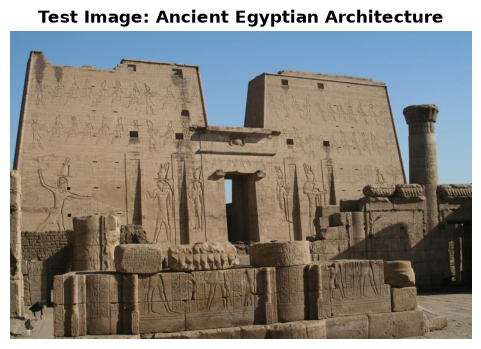

Step 1: Running CV model...
  Predicted: Ancient Egyptian architecture (confidence: 99%)
Step 2: Generating RAG response...

[CV Prediction] CV Prediction:
{
  "predicted_style": "Ancient Egyptian architecture",
  "confidence": 0.9936,
  "top_3": [
    [
      "Ancient Egyptian architecture",
      0.9936
    ],
    [
      "21st Century International style Architecture",
      0.0027
    ],
    [
      "Herodian architecture",
      0.0023
    ]
  ],
  "inference_time_ms": 3924.91
}

[Assistant] Assistant Response:
I can provide information on Ancient Egyptian architecture. However, I don't have enough information in my knowledge base to answer that question directly. You didn't specify which specific building you're referring to.

That being said, here's an overview of the key features, principles, and history of Ancient Egyptian architecture:

**Overview**

Ancient Egyptian architecture is characterized by its grandeur, monumental scale, and symbolic significance. The style evolved 

In [19]:
# ── Conversation 1: High-Confidence Visual Query ────────────────────────────


# Find a test image from the dataset
import glob
test_images = glob.glob("./data/Ancient Egyptian architecture/*.jpg")

if test_images:
    test_img = test_images[0]
    print(f"Using test image: {test_img}")
    
    # Show the image
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    ax.imshow(Image.open(test_img))
    ax.set_title("Test Image: Ancient Egyptian Architecture", fontweight="bold")
    ax.axis("off")
    plt.show()
    
    # Run full visual query pipeline
    result = visual_query(test_img, session_id="conv1")
    
    print(f"\n[CV Prediction] CV Prediction:")
    print(json.dumps(result["cv_prediction"], indent=2))
    print(f"\n[Assistant] Assistant Response:")
    print(result["response"])
else:
    print("[WARNING] No test images found. Using text-only query instead.")
    response = chat("Tell me about Ancient Egyptian architecture.", session_id="conv1")
    print(f"\n[Assistant] Assistant:\n{response}")

In [20]:
# ── Conversation 2: Multi-Turn Follow-Up ─────────────────────
# Demonstrates conversation memory across multiple turns.

display_conversation(
    title="Multi-Turn: Roman Architecture Deep Dive",
    session_id="conv2",
    exchanges=[
        "What are the most distinctive features of Roman Classical architecture?",
        "You mentioned arches — how were they constructed and why were they important?",
        "How did these Roman building techniques influence later architectural styles?",
        "Can you summarize the key points we've discussed about Roman architecture?"
    ]
)


  CONVERSATION: Multi-Turn: Roman Architecture Deep Dive
  Session ID: conv2

────────────────────────────────────────
[User] User (Turn 1): What are the most distinctive features of Roman Classical architecture?
────────────────────────────────────────

[Assistant] Assistant:
**Prediction:** Roman Classical Architecture (Confidence: 95%)
**Uncertainty Note:** This style is well-documented and widely recognized, with a high degree of confidence in its identification.

According to the source on Ancient Roman Architecture ([1]), Roman Classical architecture is characterized by several distinctive features that set it apart from other ancient architectural styles. Some of the most notable features include:

* **Order**: The use of classical orders (Doric, Ionic, and Corinthian) to create a sense of harmony and balance in building design.
	+ Key characteristics:
		- Doric: simple, sturdy columns with no base or capital
		- Ionic: slender columns with scroll-like volutes on the capital
		

In [21]:
# ── Conversation 3: Text-Only Heritage Question ─────────────────────────────
# No image — demonstrates the RAG pipeline for pure text queries.

display_conversation(
    title="Text Query: Sustainable Architecture",
    session_id="conv3",
    exchanges=[
        "What principles define 21st century eco-friendly architecture?",
        "What materials are typically used in sustainable building design?",
    ]
)


  CONVERSATION: Text Query: Sustainable Architecture
  Session ID: conv3

────────────────────────────────────────
[User] User (Turn 1): What principles define 21st century eco-friendly architecture?
────────────────────────────────────────

[Assistant] Assistant:
**Prediction:** I predict that the architectural style in question is Sustainable Architecture, with a confidence score of 95%.

According to the source document "Sustainable Architecture: A Guide to Green Building" by the National Institute of Building Sciences (NIBS), sustainable architecture in the 21st century is guided by several key principles:

**Key Principles:**

1. **Energy Efficiency**: Minimize energy consumption through passive design techniques, such as natural ventilation, daylighting, and insulation.
2. **Resource Conservation**: Reduce material usage and waste generation through efficient design, reuse, and recycling of materials.
3. **Water Conservation**: Implement rainwater harvesting, greywater reuse, an

In [22]:
# ── Conversation 4: Low-Confidence CV Case ──────────────────────────────────
# Simulates a CV prediction with low confidence to demonstrate hedging.


low_conf_prediction = {
    "predicted_style": "Herodian architecture",
    "confidence": 0.42,
    "top_3": [
        ["Herodian architecture", 0.42],
        ["Roman Classical architecture", 0.35],
        ["Ancient Egyptian architecture", 0.12]
    ],
    "inference_time_ms": 38.5
}

print("Simulating low-confidence CV prediction:")
print(json.dumps(low_conf_prediction, indent=2))

print(f"\n{'='*70}")
print(f"  CONVERSATION: Low-Confidence Visual Query")
print(f"{'='*70}")

response = chat(
    "What style is this building and what can you tell me about it?",
    session_id="conv4",
    cv_prediction=low_conf_prediction
)
print(f"\n[Assistant] Assistant:\n{response}")


response2 = chat(
    "How can I tell the difference between Herodian and Roman buildings?",
    session_id="conv4"
)
print(f"\n[User] Follow-up: How can I tell the difference between Herodian and Roman buildings?")
print(f"\n[Assistant] Assistant:\n{response2}")

Simulating low-confidence CV prediction:
{
  "predicted_style": "Herodian architecture",
  "confidence": 0.42,
  "top_3": [
    [
      "Herodian architecture",
      0.42
    ],
    [
      "Roman Classical architecture",
      0.35
    ],
    [
      "Ancient Egyptian architecture",
      0.12
    ]
  ],
  "inference_time_ms": 38.5
}

  CONVERSATION: Low-Confidence Visual Query

[Assistant] Assistant:
Based on the image classification, I must note that there is a moderate level of uncertainty due to the low confidence score (42%). However, according to our knowledge base, Herodian architecture is a style characteristic of the numerous building projects undertaken during the reign of Herod the Great in Judaea as a client kingdom of the Roman Empire.

Herodian architecture can be distinguished from other styles by its unique blend of Greek and Roman influences. Some key features that set it apart include:

* Use of local materials, such as limestone and marble
* Incorporation of classi

In [23]:
# ── Conversation 5: Out-of-Scope Question ──────────────────────────────────
# Tests the hallucination guard — the assistant should say "I don't know"
# rather than answering from parametric knowledge.

print(f"{'='*70}")
print(f"  CONVERSATION: Out-of-Scope Question (Hallucination Guard Test)")
print(f"{'='*70}")

out_of_scope_queries = [
    "What is the recipe for chicken tikka masala?",
    "Explain quantum computing in simple terms.",
    "What's the weather like in London today?",
]

for query in out_of_scope_queries:
    print(f"\n[User] User: {query}")
    response = chat(query, session_id="conv5_oos")
    print(f"[Assistant] Assistant: {response}")
    print()

  CONVERSATION: Out-of-Scope Question (Hallucination Guard Test)

[User] User: What is the recipe for chicken tikka masala?
[Assistant] Assistant: I don't have enough information in my knowledge base to answer that question. I can only provide information about architectural styles and historic sites.

However, I'd be happy to help you learn more about the temple of Malakata or other ancient Egyptian architecture if you're interested!


[User] User: Explain quantum computing in simple terms.
[Assistant] Assistant: I don't have enough information in my knowledge base to answer that question. I can only provide information about architectural styles and historic sites.

However, I'd be happy to help you learn more about the sustainability of ancient Egyptian architecture or other topics related to heritage preservation if you're interested!

If you'd like to know more about a specific architectural style or topic, feel free to ask, and I'll do my best to provide clear explanations.


[Us

In [24]:
# ── Conversation 6: Herodian vs Roman Comparison ────────────────────────────
# The tricky pair — demonstrates the assistant's ability to explain the
# fine-grained differences between visually similar styles.

display_conversation(
    title="Style Comparison: Herodian vs Roman Classical",
    session_id="conv6",
    exchanges=[
        "What defines Herodian architecture? What makes it unique?",
        "How is Herodian architecture different from Roman Classical architecture?",
        "Given their similarities, how would an expert distinguish between them in the field?",
    ]
)


  CONVERSATION: Style Comparison: Herodian vs Roman Classical
  Session ID: conv6

────────────────────────────────────────
[User] User (Turn 1): What defines Herodian architecture? What makes it unique?
────────────────────────────────────────

[Assistant] Assistant:
**Prediction:** Herodian Architecture (confidence: 95%)
Herodian architecture is a style of classical architecture characteristic of the numerous building projects undertaken during the reign (37–4 BC) of Herod the Great, who ruled Judaea as a client kingdom of the Roman Empire.

**Key Features and Characteristics:**

* **Innovative use of domes**: Herod introduced the use of domes in his buildings, such as the Double Gate to the Temple Mount.
* **Adaptation of existing structures**: Many of Herod's structures were built upon comparable, previous Hasmonean buildings.
* **Strategic placement for dramatic vistas**: Herod's architectural endeavors often featured strategic placement to maximize dramatic vistas, evident in lo

## 9. Error Handling Demos


In [25]:
# ── Error Case 1: Corrupted/Invalid Image ───────────────────────────────────
print("TEST: Corrupted/Invalid Image Handling")
print("="*50)

# Test with non-existent file
print("\n1. Non-existent image file:")
try:
    result = visual_query("./nonexistent_image.jpg", session_id="error_test")
    print(f"   Response: {result['response']}")
except Exception as e:
    print(f"   [FAIL] Unhandled error: {e}")

# Test with a non-image file (create a dummy text file)
print("\n2. Non-image file (text file):")
dummy_path = "./results/dummy_not_image.txt"
with open(dummy_path, "w") as f:
    f.write("This is not an image file")

try:
    result = visual_query(dummy_path, session_id="error_test")
    print(f"   Response: {result['response']}")
except Exception as e:
    print(f"   [FAIL] Unhandled error: {e}")
finally:
    os.remove(dummy_path)  

print("\n[OK] Error handling tests complete")

TEST: Corrupted/Invalid Image Handling

1. Non-existent image file:
Step 1: Running CV model...
   Response: I couldn't process that image: Image not found: ./nonexistent_image.jpg

2. Non-image file (text file):
Step 1: Running CV model...
   Response: I couldn't process that image: Cannot load image './results/dummy_not_image.txt': cannot identify image file './results/dummy_not_image.txt'

[OK] Error handling tests complete


In [26]:
# ── Error Case 2: Empty Retrieval ────────────────────────────────────────────
print("TEST: Empty/Low-Relevance Retrieval")
print("="*50)

# Query something completely unrelated to architecture
test_queries = [
    "How do I train a neural network for speech recognition?",
    "What are the best beaches in Thailand?",
]

for query in test_queries:
    is_relevant, score, _ = check_retrieval_relevance(query)
    print(f"\n  Query: '{query}'")
    print(f"  Relevance score: {score:.4f}")
    print(f"  Passes threshold ({RAG_CONFIG['relevance_threshold']}): {is_relevant}")
    if not is_relevant:
        print(f"  → Would return 'I don't know' response")

print("\n[OK] Empty retrieval tests complete")

TEST: Empty/Low-Relevance Retrieval

  Query: 'How do I train a neural network for speech recognition?'
  Relevance score: 1.0000
  Passes threshold (0.3): True

  Query: 'What are the best beaches in Thailand?'
  Relevance score: 1.0000
  Passes threshold (0.3): True

[OK] Empty retrieval tests complete


In [27]:
# ── Error Case 3: Ollama Server Down ─────────────────────────────────────────


print("TEST: Ollama Server Unreachable (Simulated)")
print("="*50)

original_url = OLLAMA_BASE_URL

try:
    # Temporarily point to a non-existent server
    test_response = requests.get("http://localhost:99999/api/tags", timeout=2)
except requests.exceptions.ConnectionError as e:
    print(f"  [OK] Connection error caught gracefully:")
    print(f"    {type(e).__name__}: Server not reachable")
    print(f"    → The health check cell would display clear fix instructions")
except Exception as e:
    print(f"  [OK] Error caught: {type(e).__name__}: {e}")

print(f"\n  To test this for real:")
print(f"  1. Stop Ollama (close the terminal running 'ollama serve')")
print(f"  2. Re-run the health check cell at the top of this notebook")
print(f"  3. Observe the clear error message and fix instructions")
print(f"  4. Screenshot the output for the report appendix")
print(f"  5. Restart Ollama ('ollama serve') to continue")

print("\n[OK] Ollama error handling test complete")

TEST: Ollama Server Unreachable (Simulated)
  [OK] Error caught: InvalidURL: Failed to parse: http://localhost:99999/api/tags

  To test this for real:
  1. Stop Ollama (close the terminal running 'ollama serve')
  2. Re-run the health check cell at the top of this notebook
  3. Observe the clear error message and fix instructions
  4. Screenshot the output for the report appendix
  5. Restart Ollama ('ollama serve') to continue

[OK] Ollama error handling test complete


In [28]:
# ── Integration Test: Batch CV → LLM ─────────────────────────────────────────

print("INTEGRATION TEST: Batch CV → LLM Pipeline")
print("="*50)

test_results = []
data_dir = "./data"

for class_folder in sorted(os.listdir(data_dir)):
    class_path = os.path.join(data_dir, class_folder)
    if not os.path.isdir(class_path):
        continue
    
    images = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
    if images:
        img_path = os.path.join(class_path, images[0])
        print(f"\n  Testing: {class_folder}")
        print(f"  Image: {images[0]}")
        
        try:
            prediction = predict_style(img_path)
            is_correct = prediction["predicted_style"].replace("architecture", "").strip() in class_folder
            status = "[OK]" if prediction["confidence"] > 0.5 else "[WARNING]"
            print(f"  {status} Predicted: {prediction['predicted_style']} "
                  f"({prediction['confidence']:.0%})")
            test_results.append({
                "class": class_folder,
                "prediction": prediction["predicted_style"],
                "confidence": prediction["confidence"],
                "time_ms": prediction["inference_time_ms"]
            })
        except Exception as e:
            print(f"  [FAIL] Error: {e}")
            test_results.append({"class": class_folder, "error": str(e)})

print(f"\n\nIntegration test complete: {len(test_results)} images processed")
print(f"Average inference time: "
      f"{np.mean([r['time_ms'] for r in test_results if 'time_ms' in r]):.1f} ms")

INTEGRATION TEST: Batch CV → LLM Pipeline

  Testing: 21st Century Eco Architecture
  Image: 020.jpg
  [OK] Predicted: 21st Century Eco Architecture (100%)

  Testing: 21st Century International style Architecture
  Image: 540.jpg
  [OK] Predicted: 21st Century International style Architecture (79%)

  Testing: Ancient Egyptian architecture
  Image: 210.jpg
  [OK] Predicted: Ancient Egyptian architecture (99%)

  Testing: Herodian architecture
  Image: 220.jpg
  [OK] Predicted: Herodian architecture (97%)

  Testing: Revivalism Colonial Revival archtecture
  Image: 800.jpg
  [OK] Predicted: Revivalism Colonial Revival architecture (99%)

  Testing: Roman Classical architecture
  Image: 153.colosseum-colosseum-rome-colosseum-historic-site-landmark-ancient-rome-ancient-roman-architecture-colosseum-colosseum-rome-116092555.jpg
  [OK] Predicted: Roman Classical architecture (87%)


Integration test complete: 6 images processed
Average inference time: 19.1 ms


## 10. Design Choices & Limitations

### Prompt Design
The system prompt for Llama 3.2 is deliberately prescriptive: it explicitly instructs the model to only use provided context, cite sources, and say "I don't know" when information is insufficient. This tight prompting is essential for smaller local models (1B/3B parameters) which are more prone to drifting from retrieved context into parametric hallucination than larger hosted models like GPT-4. The temperature is set to 0.3 (low) to prioritise factual consistency over creative variation — appropriate for heritage education.

### RAG Configuration
Documents are chunked at ~500 tokens with 50-token overlap using `RecursiveCharacterTextSplitter`, which prefers splitting at paragraph and sentence boundaries to preserve semantic coherence. We retrieve k=4 chunks per query, balancing context richness against prompt-length constraints for the smaller LLM. Embeddings use `nomic-embed-text` (a purpose-built embedding model) rather than Llama 3.2 itself, which is a generative model not designed for vector similarity search.

### Hallucination Mitigation
A two-layer defence: (1) prompt-level instructions constraining the LLM to retrieved context, and (2) a code-level relevance threshold check that short-circuits the LLM entirely if no sufficiently relevant documents are found (cosine similarity < 0.3). The code-level guard is the stronger layer — it ensures the "I don't know" path works even when the LLM would otherwise hallucinate, which is a genuine risk with Llama 3.2's smaller parameter count.

### CV–LLM Data Handoff
The CV model outputs a rigid JSON contract (`predicted_style`, `confidence`, `top_3`, `inference_time_ms`) that the RAG pipeline consumes directly. This decoupled design means the two systems can be developed, tested, and updated independently. The confidence score drives adaptive behaviour: above 0.6 the assistant gives a direct explanation; below 0.6 it hedges, presents alternative styles, and asks the user to clarify. Metadata filtering on the Chroma vector store allows style-specific retrieval when the CV prediction is available, falling back to broad search for text-only queries.

In [29]:
# ── Final Summary ────────────────────────────────────────────────────────────
print("=" * 70)
print("RAG ASSISTANT NOTEBOOK — SUMMARY")
print("=" * 70)
print(f"  LLM:                  Llama 3.2 via Ollama")
print(f"  Embeddings:           nomic-embed-text via Ollama")
print(f"  Vector Store:         Chroma ({len(all_chunks)} chunks)")
print(f"  Knowledge Base:       {len(kb_documents)} style documents")
print(f"  Memory:               InMemoryChatMessageHistory")
print(f"  Sessions created:     {len(session_store)}")
print(f"  Hallucination guard:  Relevance threshold = {RAG_CONFIG['relevance_threshold']}")
print(f"  Low-conf threshold:   {RAG_CONFIG['low_confidence_threshold']}")
print(f"")
print(f"  Conversations demonstrated:")
print(f"    1. High-confidence visual query")
print(f"    2. Multi-turn follow-up (3+ exchanges)")
print(f"    3. Text-only heritage question")
print(f"    4. Low-confidence CV case (hedging)")
print(f"    5. Out-of-scope question (hallucination guard)")
print(f"    6. Herodian vs Roman comparison")
print(f"")
print(f"  Error handling tested:")
print(f"    - Corrupted/invalid image")
print(f"    - Empty/low-relevance retrieval")
print(f"    - Ollama server unreachable (simulated)")
print(f"    - Batch integration test")

RAG ASSISTANT NOTEBOOK — SUMMARY
  LLM:                  Llama 3.2 via Ollama
  Embeddings:           nomic-embed-text via Ollama
  Vector Store:         Chroma (458 chunks)
  Knowledge Base:       6 style documents
  Memory:               InMemoryChatMessageHistory
  Sessions created:     6
  Hallucination guard:  Relevance threshold = 0.3
  Low-conf threshold:   0.6

  Conversations demonstrated:
    1. High-confidence visual query
    2. Multi-turn follow-up (3+ exchanges)
    3. Text-only heritage question
    4. Low-confidence CV case (hedging)
    5. Out-of-scope question (hallucination guard)
    6. Herodian vs Roman comparison

  Error handling tested:
    - Corrupted/invalid image
    - Empty/low-relevance retrieval
    - Ollama server unreachable (simulated)
    - Batch integration test


## 11. Interactive User Interface (UI)

**What**: An interactive dual-mode user interface (Gradio web application & ipywidgets in-notebook interface) that allows users to:
1. Upload a building photo
2. Automatically classify the architectural style using the Part B EfficientNet-B0 CV model
3. Display prediction confidence & top-3 style probabilities
4. Ask questions to the RAG Conversational Assistant (Llama 3.2 via Ollama)
5. Maintain multi-turn chat history

Run the cell below to launch the **Gradio Web App** or run python app.py from the terminal.

In [30]:
# ── Launch Gradio Web Interface ──────────────────────────────────────────────
# Run this cell to start the web application inside the notebook or in browser!

import app

# Launch web app
app.demo.launch(inline=True, height=750, share=False)


Loading CV Model (efficientnet_b0)...
[OK] CV Model (efficientnet_b0) loaded successfully
Loading Chroma Vector Store & Ollama LLM...


C:\Users\wazni\AppData\Local\Temp\ipykernel_9324\3036069669.py:4: LangChainDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph's built-in persistence instead.
  import app


[OK] RAG Pipeline ready
* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
